### Loading datasets

In [1]:
import torchvision
import numpy as np
import skdim

RNG = np.random.default_rng(42)
N = 2000  # samples per dataset

# ── KINK: balanced 2D classification with kinked (V-shape) boundary ───────────
def make_kink(n=N, margin=0.25, seed=42):
    """Uniform samples in [-1,1]^2 with balanced classes separated by y = -|x|."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1, 1, (n * 8, 2))
    dist  = X[:, 1] - (-np.abs(X[:, 0]))
    above = dist >  margin / 2
    below = dist < -margin / 2
    idx1  = np.where(above)[0][:n // 2]
    idx0  = np.where(below)[0][:n // 2]
    idx   = np.concatenate([idx0, idx1])
    rng.shuffle(idx)
    return X[idx], (above[idx]).astype(int)

X_kink, y_kink = make_kink()

# ── MNIST 0 vs 7 ─────────────────────────────────────────────────────────────
mnist_ds = torchvision.datasets.MNIST('./data', train=True, download=True)
idx07    = (mnist_ds.targets == 0) | (mnist_ds.targets == 7)
X_all    = mnist_ds.data[idx07].float().numpy().reshape(-1, 784) / 255.0
y_all    = (mnist_ds.targets[idx07] == 7).numpy().astype(int)
sel      = RNG.choice(len(X_all), N, replace=False)
X_mnist, y_mnist = X_all[sel], y_all[sel]

# ── CIFAR-10: automobile (1) vs deer (4) ─────────────────────────────────────
# Two classes with fairly different visual structure, both natural images.
CIFAR_C0, CIFAR_C1 = 1, 4   # automobile vs deer
cifar_ds = torchvision.datasets.CIFAR10('./data', train=True, download=True)
cifar_targets = np.array(cifar_ds.targets)
idx_c  = (cifar_targets == CIFAR_C0) | (cifar_targets == CIFAR_C1)
X_c_all = np.array(cifar_ds.data)[idx_c].reshape(-1, 32 * 32 * 3) / 255.0
y_c_all = (cifar_targets[idx_c] == CIFAR_C1).astype(int)
sel_c   = RNG.choice(len(X_c_all), N, replace=False)
X_cifar, y_cifar = X_c_all[sel_c], y_c_all[sel_c]

CIFAR_LABELS = {CIFAR_C0: 'automobile', CIFAR_C1: 'deer'}
print(f"KINK    : shape={X_kink.shape},  classes={np.bincount(y_kink)}")
print(f"MNIST0,7: shape={X_mnist.shape}, classes={np.bincount(y_mnist)}")
print(f"CIFAR   : shape={X_cifar.shape}, classes={np.bincount(y_cifar)}  "
      f"({CIFAR_LABELS[CIFAR_C0]} vs {CIFAR_LABELS[CIFAR_C1]})")

X_all = [X_kink, X_mnist, X_cifar]

KINK    : shape=(2000, 2),  classes=[1000 1000]
MNIST0,7: shape=(2000, 784), classes=[ 976 1024]
CIFAR   : shape=(2000, 3072), classes=[1018  982]  (automobile vs deer)


# Default results

In [ ]:
# ── Global ID estimators ──────────────────────────────────────────────────────

for X in X_all:
    # Correlation Dimension (Grassberger-Procaccia 1983)
    # Default k1=10, k2=20, n_bins=20, n_jobs=-1
    corr_sim = skdim.id.CorrInt().fit(X)

    # Concentration Algorithm
    # Default k=10, D=None, ver='DANCo', fractal=True, n_jobs=-1
    concentration = skdim.id.DANCo().fit(X)

    # Expected Simplex Skewness algorithm
    # ver='a', d=1, 
    simplex_skewness = skdim.id.ESS().fit(X)

    # FisherS (Albergante et al. 2019)
    # conditional_number=10, project_on_sphere=True, 
    # alphas=np.arange(0.6,1,0.02)[None], limit_maxdim=False
    fisher = skdim.id.FisherS().fit(X)

    # kNN 
    # k=None, ps=None, M=1, gamma=2, n_jobs=-1
    knn = skdim.id.KNN().fit(X)

    # PCA
    # ver='FO', alphaFO=0.05, alphaRatio=0.05, alphaFan=10, betaFan=0.8, PFan=0.95
    pca = skdim.id.lPCA().fit(X)

    # Manifold-Adaptive Dimension Estimation algorithm
    # DM=False
    manifold = skdim.id.MADA().fit(X)

    # MiND_MLk
    # k=20, D=10, ver='MLk'
    mind = skdim.id.MiND_ML().fit(X)

    # MLE
    # K=5, integral_approximation='Haro', unbiased=False, neighborhood_based=True
    mle = skdim.id.MLE().fit(X)

    # MoM
    # No hyperp.
    mom = skdim.id.MOM().fit(X)

    # Tight Local 
    # epsilon (small positive; library-internal default)
    tle = skdim.id.TLE().fit(X)

    # TwoNN
    # discard_fraction=0.1, dist=False
    twonn = skdim.id.TwoNN().fit(X)

    print(f"{'Estimator':<25} {'ID estimate':>12}")
    print("-" * 38)

    print(f"{'Correlation Dimension':<25} {corr_sim.dimension_:>12.2f}")
    print(f"{'Concentration':<25} {concentration.dimension_:>12.2f}")
    print(f"{'Expected Simplex Skewness':<25} {simplex_skewness.dimension_:>12.2f}")
    print(f"{'FisherS':<25} {fisher.dimension_:>12.2f}")
    print(f"{'kNN':<25} {knn.dimension_:>12.2f}")
    print(f"{'PCA':<25} {pca.dimension_:>12.2f}")
    print(f"{'Manifold-Adaptive':<25} {manifold.dimension_:>12.2f}")
    print(f"{'MiND_ML':<25} {mind.dimension_:>12.2f}")
    print(f"{'MLE':<25} {mle.dimension_:>12.2f}")
    print(f"{'MoM':<25} {mom.dimension_:>12.2f}")
    print(f"{'Tight Local':<25} {tle.dimension_:>12.2f}")
    print(f"{'TwoNN':<25} {twonn.dimension_:>12.2f}")


Estimator                  ID estimate
--------------------------------------
Correlation Dimension             1.89
Concentration                     2.00
Expected Simplex Skewness         1.97
FisherS                           1.88
kNN                               1.00
PCA                               2.00
Manifold-Adaptive                 2.12
MiND_ML                           2.00
MLE                               1.95
MoM                               1.91
Tight Local                       2.12
TwoNN                             1.91
Estimator                  ID estimate
--------------------------------------
Correlation Dimension             8.17
Concentration                   784.00
Expected Simplex Skewness        16.84
FisherS                           5.71
kNN                               6.00
PCA                              16.00
Manifold-Adaptive                11.98
MiND_ML                          10.00
MLE                              11.12
MoM                      

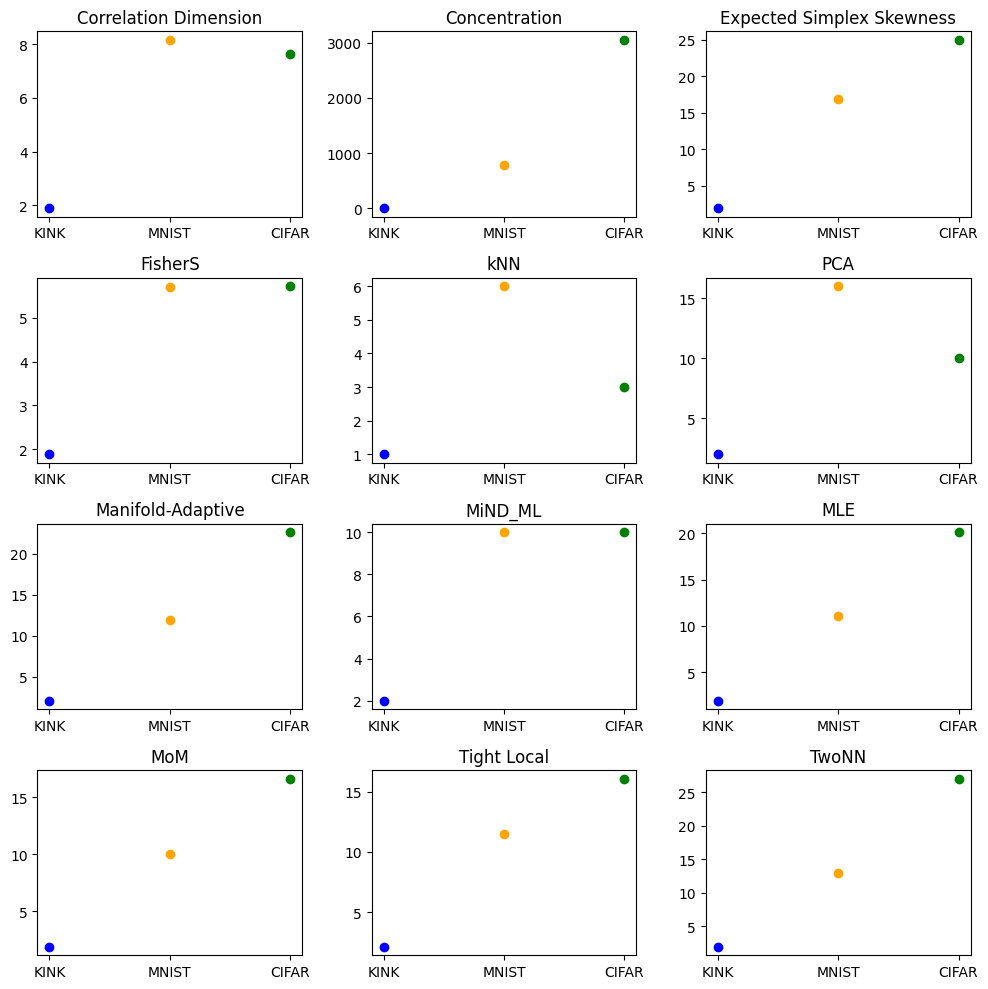

In [ ]:
import matplotlib.pyplot as plt

Estimator = ["Correlation Dimension","Concentration","Expected Simplex Skewness","FisherS","kNN","PCA","Manifold-Adaptive",
                "MiND_ML","MLE","MoM","Tight Local","TwoNN"]

kink = [1.89, 2.00, 1.97, 1.88, 1.00, 2.00, 2.12, 2.00, 1.95, 1.91, 2.12, 1.91]

mnist = [8.17, 784.00, 16.84, 5.71, 6.00, 16.00, 11.98, 10.00, 11.12, 10.06, 11.45, 12.98]

cifar = [7.62, 3055.77, 25.02, 5.73, 3.00, 10.00, 22.64, 10.00, 20.11, 16.62, 16.08, 27.03]

datasets = ["KINK", "MNIST", "CIFAR"]

fig, ax = plt.subplots(4, 3, figsize=(10, 10))
ax_flat = ax.flatten()

k=0
for est, k_val, m, c in zip(Estimator, kink, mnist, cifar):
    ax_flat[k].scatter(datasets[0], k_val, color='blue')
    ax_flat[k].scatter(datasets[1], m, color='orange')
    ax_flat[k].scatter(datasets[2], c, color='green')
    ax_flat[k].set_title(est)
    k += 1

plt.tight_layout()
plt.show()

# Hyperparameters cross-check

In [2]:
import pandas as pd

datasets = {"KINK": X_kink, "MNIST": X_mnist, "CIFAR": X_cifar}

# Each entry: (group_name, [(param_label, estimator), ...])
# DANCo is slow — comment it out if time is a concern
sweep = [
    ("KNN", [
        ("k=5",  skdim.id.KNN(k=5)),
        ("k=10", skdim.id.KNN(k=10)),
        ("k=20", skdim.id.KNN(k=20)),
        ("k=40", skdim.id.KNN(k=40)),
    ]),
    ("CorrInt", [
        ("k1=5,k2=15",  skdim.id.CorrInt(k1=5,  k2=15)),
        ("k1=10,k2=20", skdim.id.CorrInt(k1=10, k2=20)),
        ("k1=20,k2=40", skdim.id.CorrInt(k1=20, k2=40)),
    ]),
    ("DANCo", [
        ("k=5",  skdim.id.DANCo(k=5)),
        ("k=10", skdim.id.DANCo(k=10)),
        ("k=20", skdim.id.DANCo(k=20)),
    ]),
    ("MiND_ML", [
        ("k=10,MLk", skdim.id.MiND_ML(k=10, ver='MLk')),
        ("k=10,MLi", skdim.id.MiND_ML(k=10, ver='MLi')),
        ("k=20,MLk", skdim.id.MiND_ML(k=20, ver='MLk')),
        ("k=20,MLi", skdim.id.MiND_ML(k=20, ver='MLi')),
    ]),
    ("MLE", [
        ("K=5,Haro",              skdim.id.MLE(K=5)),
        ("K=10,Haro",             skdim.id.MLE(K=10)),
        ("K=20,Haro",             skdim.id.MLE(K=20)),
        ("K=10,guar.conv",        skdim.id.MLE(K=10, integral_approximation='guaranteed.convergence')),
        ("K=10,iter",             skdim.id.MLE(K=10, integral_approximation='iteration')),
    ]),
    ("lPCA", [
        ("FO",      skdim.id.lPCA(ver='FO')),
        ("ratio",   skdim.id.lPCA(ver='ratio')),
        ("maxgap",  skdim.id.lPCA(ver='maxgap')),
        ("Kaiser",  skdim.id.lPCA(ver='Kaiser')),
        ("broken_stick", skdim.id.lPCA(ver='broken_stick')),
    ]),
    ("TwoNN", [
        ("discard=0.05", skdim.id.TwoNN(discard_fraction=0.05)),
        ("discard=0.10", skdim.id.TwoNN(discard_fraction=0.10)),
        ("discard=0.25", skdim.id.TwoNN(discard_fraction=0.25)),
    ]),
    ("ESS", [
        ("ver=a", skdim.id.ESS(ver='a')),
        ("ver=b", skdim.id.ESS(ver='b')),
    ]),
]

rows = []
for group, configs in sweep:
    for param_label, est in configs:
        row = {"Estimator": group, "Params": param_label}
        for ds_name, X in datasets.items():
            try:
                d = est.fit(X).dimension_
                row[ds_name] = round(float(d), 2)
            except Exception as exc:
                row[ds_name] = f"ERR: {exc}"
        rows.append(row)

df = pd.DataFrame(rows).set_index(["Estimator", "Params"])
with pd.option_context("display.max_rows", 200, "display.float_format", "{:.2f}".format):
    display(df)


KINK  \
Estimator Params                                                              
KNN       k=5                                                          1.00   
          k=10                                                         1.00   
          k=20                                                         1.00   
          k=40                                                         2.00   
CorrInt   k1=5,k2=15                                                   1.92   
          k1=10,k2=20                                                  1.89   
          k1=20,k2=40                                                  1.85   
DANCo     k=5                                                          2.00   
          k=10                                                         2.00   
          k=20                                                         2.00   
MiND_ML   k=10,MLk                                                     2.00   
          k=10,MLi                                                     2.00   
          k=20,MLk                                                     2.00   
          k=20,MLi                                                     2.00   
MLE       K=5,Haro                                                     1.95   
          K=10,Haro                                                    1.95   
          K=20,Haro                                                    1.95   
          K=10,guar.conv                                               1.95   
          K=10,iter       ERR: integral_approximation='iteration' not im...   
lPCA      FO                                                           2.00   
          ratio                                                        1.00   
          maxgap                                                       1.00   
          Kaiser                                                       1.00   
          broken_stick                                                 1.00   
TwoNN     discard=0.05                                                 1.91   
          discard=0.10                                                 1.91   
          discard=0.25                                                 1.93   
ESS       ver=a                                                        1.97   
          ver=b                                                        1.95   

                                                                      MNIST  \
Estimator Params                                                              
KNN       k=5                                                          5.00   
          k=10                                                         3.00   
          k=20                                                         3.00   
          k=40                                                         2.00   
CorrInt   k1=5,k2=15                                                   8.51   
          k1=10,k2=20                                                  8.17   
          k1=20,k2=40                                                  7.75   
DANCo     k=5                                                        782.93   
          k=10                                                       781.29   
          k=20                                                       783.27   
MiND_ML   k=10,MLk                                                    10.00   
          k=10,MLi                                                    10.00   
          k=20,MLk                                                    10.00   
          k=20,MLi                                                    10.00   
MLE       K=5,Haro                                                    11.12   
          K=10,Haro                                                   11.12   
          K=20,Haro                                                   11.12   
          K=10,guar.conv                                              11.12   
          K=10,iter       ERR: integral_a

# Post-processing

In [39]:
import pandas as pd

# ── Load saved sweep results ──────────────────────────────────────────────────
output_path = "output.txt"

# Use header=0 (first <thead> row only) to avoid MultiIndex ambiguity across parsers.
# The five columns are: Estimator, Params, KINK, MNIST, CIFAR — always in that order.
raw = pd.read_html(output_path, header=0)[0]
raw.columns = ["Estimator", "Params", "KINK", "MNIST", "CIFAR"]

# Some parsers leak the second <thead> row ("Estimator / Params / …") into the body.
raw = raw[raw["Estimator"] != "Estimator"].reset_index(drop=True)

df = raw.set_index(["Estimator", "Params"])

# ── Coerce to numeric (ERR strings become NaN) ────────────────────────────────
df_num = df.apply(pd.to_numeric, errors="coerce")

# ── Calibration filter: keep rows that recover the known KINK ID ≈ 2 ──────────
KINK_TRUE = 2.0
tol = 0.5
calibrated = df_num[df_num["KINK"].between(KINK_TRUE - tol, KINK_TRUE + tol)]

print(f"Total configs : {len(df_num)}")
print(f"Passing filter (KINK ∈ [{KINK_TRUE-tol}, {KINK_TRUE+tol}]): {len(calibrated)}\n")
print("Dropped (failed KINK calibration):")
display(df_num[~df_num.index.isin(calibrated.index)])

print("\n── Calibrated results ───────────────────────────────────────────")
display(calibrated)

print("\n── Median ID per dataset (calibrated) ──────────────────────────")
print(calibrated.median().round(2))

print("\n── Std dev per dataset (calibrated) ────────────────────────────")
print(calibrated.std().round(2))

kink_lt_mnist = (calibrated["KINK"] <= calibrated["MNIST"]).all()
mnist_lt_cifar = (calibrated["MNIST"] <= calibrated["CIFAR"]).all()
print(f"\nRanking KINK <= MNIST holds for all calibrated configs : {kink_lt_mnist}")
print(f"Ranking MNIST <= CIFAR holds for all calibrated configs: {mnist_lt_cifar}")


Total configs : 29
Passing filter (KINK ∈ [1.5, 2.5]): 21

Dropped (failed KINK calibration):


KINK  MNIST   CIFAR
Estimator Params                           
KNN       k=5            1.0    5.0  3072.0
          k=10           1.0    3.0     2.0
          k=20           1.0    3.0     9.0
MLE       K=10,iter      NaN    NaN     NaN
lPCA      ratio          1.0    1.0     1.0
          maxgap         1.0  574.0  1999.0
          Kaiser         1.0   72.0   143.0
          broken_stick   1.0   36.0    54.0


── Calibrated results ───────────────────────────────────────────


KINK   MNIST    CIFAR
Estimator Params                               
KNN       k=40            2.00    2.00     1.00
CorrInt   k1=5,k2=15      1.92    8.51     7.72
          k1=10,k2=20     1.89    8.17     7.62
          k1=20,k2=40     1.85    7.75     7.38
DANCo     k=5             2.00  782.93  3068.01
          k=10            2.00  781.29  3072.00
          k=20            2.00  783.27  3061.76
MiND_ML   k=10,MLk        2.00   10.00    10.00
          k=10,MLi        2.00   10.00    10.00
          k=20,MLk        2.00   10.00    10.00
          k=20,MLi        2.00   10.00    10.00
MLE       K=5,Haro        1.95   11.12    20.11
          K=10,Haro       1.95   11.12    20.11
          K=20,Haro       1.95   11.12    20.11
          K=10,guar.conv  1.95   11.12    20.11
lPCA      FO              2.00   16.00    10.00
TwoNN     discard=0.05    1.91   12.96    26.04
          discard=0.10    1.91   12.98    27.03
          discard=0.25    1.93   13.07    28.03
ESS       ver=a           1.97   16.84    25.02
          ver=b           1.95   16.54    25.47


── Median ID per dataset (calibrated) ──────────────────────────
KINK      1.95
MNIST    11.12
CIFAR    20.11
dtype: float64

── Std dev per dataset (calibrated) ────────────────────────────
KINK        0.04
MNIST     276.63
CIFAR    1094.16
dtype: float64

Ranking KINK <= MNIST holds for all calibrated configs : True
Ranking MNIST <= CIFAR holds for all calibrated configs: False


## Why KINK has known ID = 2

`make_kink` samples points uniformly from $[-1,1]^2$ and keeps those whose distance to the boundary $y = -|x|$ exceeds a margin. Both retained classes occupy **open subsets of $\mathbb{R}^2$** with positive area, so every neighbourhood is locally homeomorphic to a 2D disk — ID = 2 by construction.

This contrasts with:
- a **curve** in $\mathbb{R}^2$ → ID = 1 (1-free parameter per point)
- a **surface** embedded in $\mathbb{R}^d$, $d > 2$ → ID = 2, ambient $d$

KINK's ambient dim equals its intrinsic dim (both 2), so it is the ideal **calibration dataset**: any estimator that fails to return ≈ 2 on KINK is misspecified or numerically unstable and should be excluded from conclusions about MNIST/CIFAR.

In [38]:
calibrated_danco_out = df_num[
    df_num["KINK"].between(KINK_TRUE - tol, KINK_TRUE + tol)
    & ~df_num.index.get_level_values("Estimator").isin(["DANCo"])
]
print("\n── Calibrated results (excluding DANCo) ───────────────────────────────────────────")
display(calibrated_danco_out)

print("\n── Median ID per dataset (calibrated, excluding DANCo) ──────────────────────────")
print(calibrated_danco_out.median().round(2))

print("\n── Std dev per dataset (calibrated, excluding DANCo) ────────────────────────────")
print(calibrated_danco_out.std().round(2))


── Calibrated results (excluding DANCo) ───────────────────────────────────────────


KINK  MNIST  CIFAR
Estimator Params                            
KNN       k=40            2.00   2.00   1.00
CorrInt   k1=5,k2=15      1.92   8.51   7.72
          k1=10,k2=20     1.89   8.17   7.62
          k1=20,k2=40     1.85   7.75   7.38
MiND_ML   k=10,MLk        2.00  10.00  10.00
          k=10,MLi        2.00  10.00  10.00
          k=20,MLk        2.00  10.00  10.00
          k=20,MLi        2.00  10.00  10.00
MLE       K=5,Haro        1.95  11.12  20.11
          K=10,Haro       1.95  11.12  20.11
          K=20,Haro       1.95  11.12  20.11
          K=10,guar.conv  1.95  11.12  20.11
lPCA      FO              2.00  16.00  10.00
TwoNN     discard=0.05    1.91  12.96  26.04
          discard=0.10    1.91  12.98  27.03
          discard=0.25    1.93  13.07  28.03
ESS       ver=a           1.97  16.84  25.02
          ver=b           1.95  16.54  25.47


── Median ID per dataset (calibrated, excluding DANCo) ──────────────────────────
KINK      1.95
MNIST    11.12
CIFAR    15.06
dtype: float64

── Std dev per dataset (calibrated, excluding DANCo) ────────────────────────────
KINK     0.04
MNIST    3.53
CIFAR    8.48
dtype: float64


### Manifold dimension estimation

The estimation consists of a multi-estimator benchmarking, a calibration-based filtering, and a hyperparameter sensitivity analysis.

We estimate the intrinsic dimensionality of each dataset using a suite of estimators from the skdim library, calibrated against a synthetic 2D manifold.

We conclude Ranking KINK < MNIST < CIFAR holds: 1.95 < 11.12 < 15.06.